In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
import scanpy as sc
import torch
import scarches as sca
from scarches.dataset.trvae.data_handling import remove_sparsity
import matplotlib.pyplot as plt
import numpy as np
import gdown

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 captum (see https://github.com/pytorch/captum).


In [3]:
import pandas as pd

In [13]:
import scvi

In [4]:
sc.settings.set_figure_params(dpi=200, frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(4, 4))
torch.set_printoptions(precision=3, sci_mode=False, edgeitems=7)

## Tissue

## load query

In [6]:
haniffaAd = sc.read_h5ad('haniffalab_QC.h5ad')

In [7]:
haniffaAd.obs.columns

Index(['disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location',
       'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue',
       'dataset_id', 'doublet_scores', 'predicted_doublets',
       'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes'],
      dtype='object')

In [8]:
haniffaAd.obs["cell_type"].value_counts()

Th                    55168
nan                   34175
Tc                    15952
Treg                  13071
Inf_mono               7970
moDC_1                 7464
Macro_1                7179
Mono                   7131
LC_3                   6231
LC_4                   5897
moDC_2                 5534
Pericyte_2_inflamm     5253
DC2                    5113
LE2                    5091
LC_2                   4747
MigDC                  4408
ILC1_3                 3932
moDC_3                 3815
ILC1_NK                3323
Macro_2                2710
DC1                    1936
LC_1                   1812
Mast_cell               897
NK                      886
ILC2                    666
Plasma                   82
Name: cell_type, dtype: int64

In [9]:
removed_cells = ['Differentiated_KC', 'Proliferating_KC', 'VE2', 'F2', 'Undifferentiated_KC*', 'Pericyte_2_inflamm',
                                                           'Differentiated_KC*', 'F1', 'VE1', 'F3', 'Pericyte_1_non_inflamm', 'Melanocyte',
                                                           'VE3', 'LE1', 'Schwann1', 'Schwann2']

In [10]:
removed_cells

['Differentiated_KC',
 'Proliferating_KC',
 'VE2',
 'F2',
 'Undifferentiated_KC*',
 'Pericyte_2_inflamm',
 'Differentiated_KC*',
 'F1',
 'VE1',
 'F3',
 'Pericyte_1_non_inflamm',
 'Melanocyte',
 'VE3',
 'LE1',
 'Schwann1',
 'Schwann2']

In [11]:
haniffaAd

AnnData object with n_obs × n_vars = 210443 × 33538
    obs: 'disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue', 'dataset_id', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes'
    var: 'gene_ids-SKN8090524', 'feature_types-SKN8090524', 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p'
    layers: 'counts'

In [12]:
haniffaAd = haniffaAd[~haniffaAd.obs.cell_type.isin(removed_cells)]

In [13]:
#haniffaAd.var = haniffaAd.var[['gene_ids-SKN8090524', 'feature_types-SKN8090524']]

In [14]:
#haniffaAd.obs["tissue"] = haniffaAd.obs.Tissue
haniffaAd.obs["dataset_id"] = "Skin_Reynolds_et_al"

In [15]:
haniffaAd.obs.columns

Index(['disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location',
       'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue',
       'dataset_id', 'doublet_scores', 'predicted_doublets',
       'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes'],
      dtype='object')

In [16]:
#haniffaAd.obs.columns = ['disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 
   #                      'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue', 'dataset_id']

In [17]:
adata_Braga = sc.read_h5ad("Braga_asthma_lung_celltypist.h5ad")

In [18]:
adata_Braga = adata_Braga[adata_Braga.obs.main_predicted_cell_groups.isin(['Classical monocytes', 'Mast cells', 'CD4 T cells', 
                                                           'DC2', 'CD8 T cells', 'Non-classical monocytes', 'NK cells', 
                                                           'B cells', 'Alveolar macrophages', 'Plasmacytoid DCs', 'Plasma cells'])].copy()

In [19]:
adata_query = adata_Braga.concatenate(haniffaAd, batch_key="ref_query")

In [20]:
del haniffaAd
del adata_Braga
adata_query

AnnData object with n_obs × n_vars = 223443 × 31915
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'main_predicted_cell_groups', 'leiden', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 'development_stage', 'cell_type', 'ref_query'
    var: 'gene_ids-SKN8090524-1', 'feature_types-SKN8090524-1', 'mt-1', 'rb-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1'
    layers: 'counts'

In [21]:
adata_query.obs.dataset_id.value_counts()

Skin_Reynolds_et_al    205190
Braga_asthma            18253
Name: dataset_id, dtype: int64

## load reference

In [5]:
adata_ref = sc.read_h5ad("Myeloid_B_T_From_Tissue_label_transfert_Subset_annotated_Milo_3K.h5ad")

In [22]:
commonGen = [gen for gen in adata_query.var_names if gen in adata_ref.var_names]

In [23]:
commonGen[:10]

['FAM87B',
 'LINC00115',
 'SAMD11',
 'NOC2L',
 'KLHL17',
 'PLEKHN1',
 'HES4',
 'ISG15',
 'AGRN',
 'RNF223']

In [24]:
adata_ref = adata_ref[:, commonGen]

In [25]:
adata_ref

View of AnnData object with n_obs × n_vars = 365203 × 17209
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0', 'total_counts-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0', 'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0', 'gene_symbol-1-0-0-0-0-0-0-1-1-0', 'n_c

In [26]:
sc.pp.highly_variable_genes(
    adata_ref,
    n_top_genes=5000,
    batch_key="dataset_id",
    subset=True)

In [27]:
adata_ref.X = adata_ref.raw[:, adata_ref.var_names].X

In [28]:
adata_ref

AnnData object with n_obs × n_vars = 365203 × 5000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0', 'total_counts-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0', 'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0', 'gene_symbol-1-0-0-0-0-0-0-1-1-0', 'n_cells_by_c

## Load SCANVI model

In [30]:
scanvae = sca.models.SCANVI.load_query_data(
    adata_ref,
    "ref_model_tissue_for_asthma_and_skin_scanvi/",
    freeze_dropout = True,
)

INFO     File ref_model_tissue_for_asthma_and_skin_scanvi/model.pt already downloaded                              


In [32]:
scanvae.train()

INFO     Training for 22 epochs.                                                                                   


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 22/22: 100%|██████████| 22/22 [27:09<00:00, 72.59s/it, v_num=1, train_loss_step=1.02e+3, train_loss_epoch=1.02e+3]

INFO: `Trainer.fit` stopped: `max_epochs=22` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=22` reached.


Epoch 22/22: 100%|██████████| 22/22 [27:10<00:00, 74.09s/it, v_num=1, train_loss_step=1.02e+3, train_loss_epoch=1.02e+3]


In [33]:
reference_latent = sc.AnnData(scanvae.get_latent_representation())

In [34]:
reference_latent.obs = adata_ref.obs

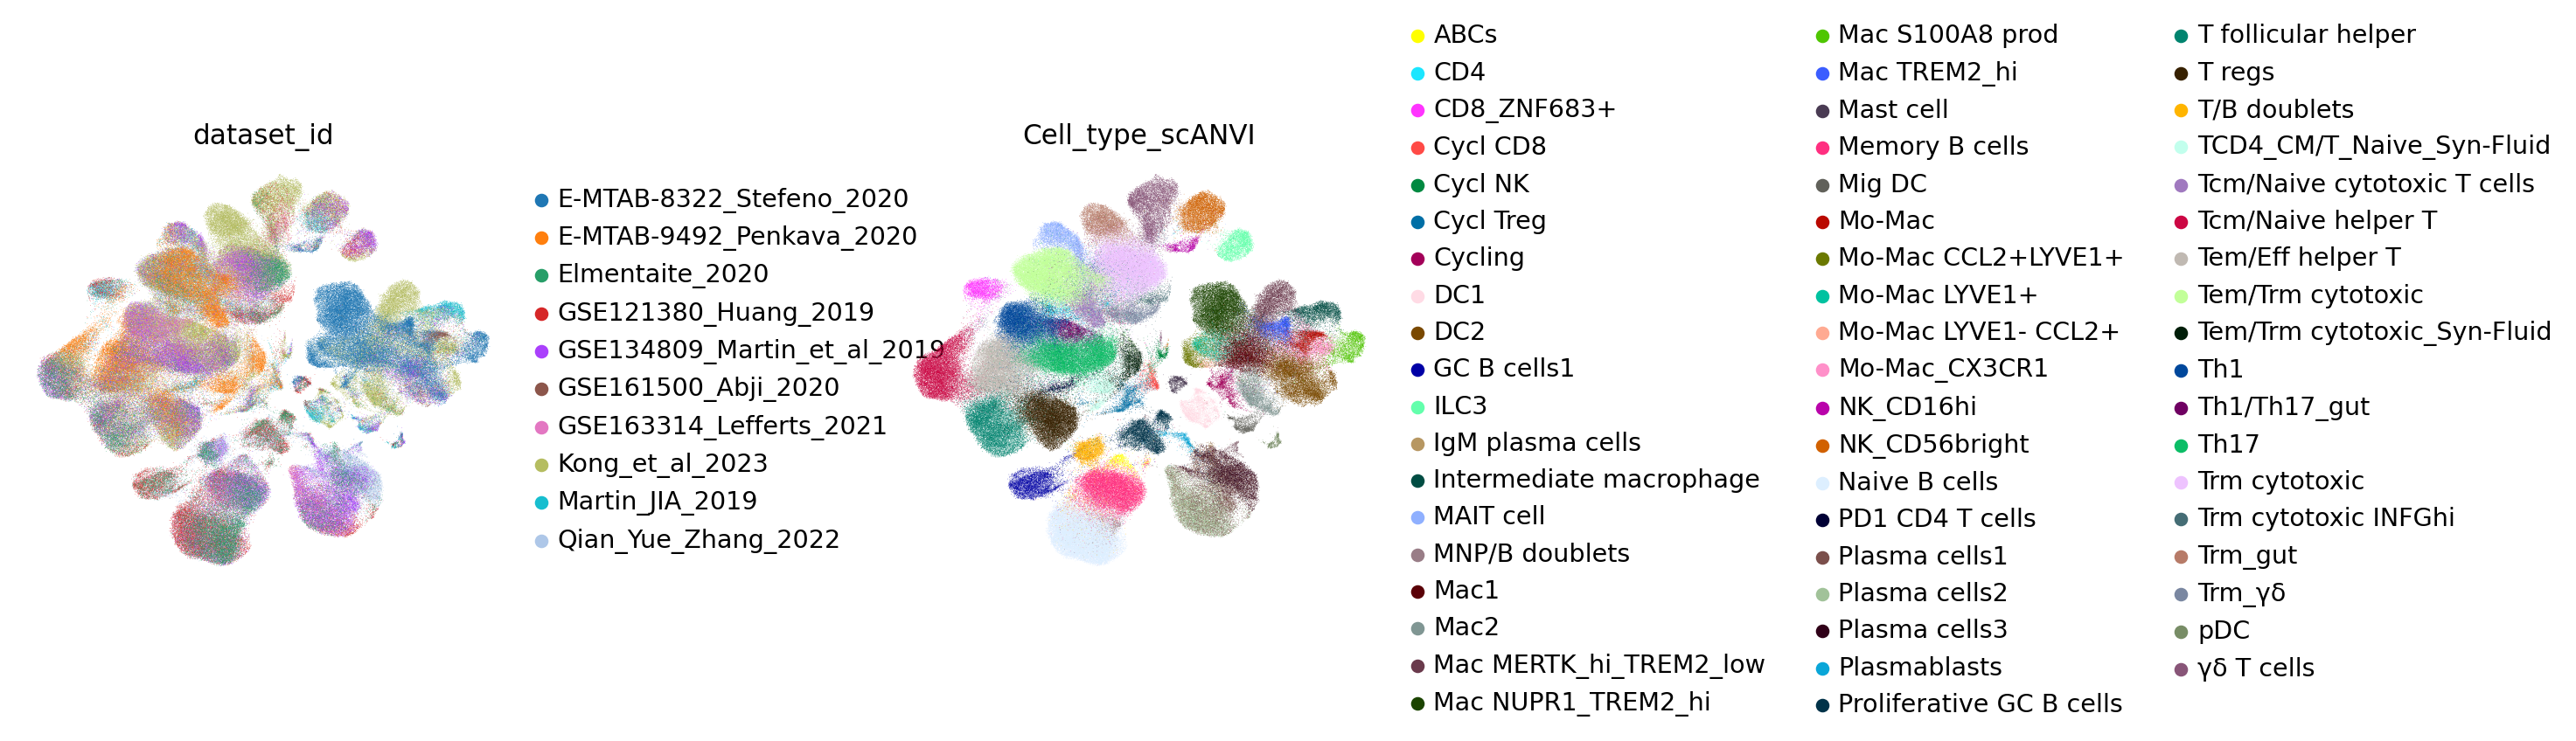

In [35]:
sc.pp.neighbors(reference_latent, n_neighbors=8)
sc.tl.leiden(reference_latent)
sc.tl.umap(reference_latent)
sc.pl.umap(reference_latent,
           color=['dataset_id', 'Cell_type_scANVI'],
           frameon=False,
           wspace=0.6,
           )

In [36]:
reference_latent.write_h5ad("Latent_representation/Latent_representation_Tissue_reference_Myeloid_T_B_Cells.h5ad")

In [37]:
!rclone copy Reintegrate_for_plotting.ipynb\
'gdrive:gcp_gpu/data_gpu/'

In [38]:
!rclone copy Latent_representation/\
'gdrive:gcp_gpu/data_gpu/Latent_representation/'

## PBMCs

In [5]:
adata = sc.read_h5ad('Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K.h5ad')

In [6]:
adata.var.columns

Index(['mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0',
       'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0',
       'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0',
       'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0',
       'pct_dropout_by_counts-1-0-0-0-0', 'total_counts-1-0-0-0-0',
       'feature_biotype-1-0-0-0-0', 'feature_is_filtered-1-0-0-0-0',
       'feature_name-1-0-0-0-0', 'feature_reference-1-0-0-0-0',
       'feature_biotype-1-0-0-0', 'feature_is_filtered-1-0-0-0',
       'feature_name-1-0-0-0', 'feature_reference-1-0-0-0', 'mt-1-0-0-0',
       'rb-1-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0',
       'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'mt-1-0-0',
       'rb-1-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0',
       'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0',
       'feature_biotype-1-0', 'feature_is_filtered-1-0', 'feature_name-1-0',
       'feature_reference-1-0', 'mt-1-0', 

In [7]:
adata.obs.columns

Index(['tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source',
       'doublet_scores', 'predicted_doublets', 'n_genes_by_counts',
       'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb',
       'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation',
       'disease_state', 'age', 'batch', 'n_genes', 'batch_2', '_scvi_batch',
       'cell_type', '_scvi_labels', 'barcodes', 'predicted_labels',
       'majority_voting', 'conf_score', 'leiden', 'Cell_type_scANVI',
       'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined',
       'nhood_kth_distance'],
      dtype='object')

In [8]:
adata.obs['batch'].value_counts()

0    579351
1    246528
2     93555
Name: batch, dtype: int64

In [9]:
sc.pp.highly_variable_genes(
    adata, 
    flavor="seurat_v3", 
    n_top_genes=2000, 
    layer="counts", 
    batch_key="dataset_id",
    subset=True
)

In [10]:
adata.obs[['dataset_id', 'tissue']].value_counts()

dataset_id                   tissue
Perez_2022                   Blood     688094
GSE157278_Hong_2020          Blood      53732
Qian_Yue_Zhang_2022          Blood      51585
GSE163314_Lefferts_2021      Blood      47708
E-MTAB-9492_Penkava_2020     Blood      32952
Martin_JIA_2019              Blood      24019
GSE134809_Martin_et_al_2019  Blood      20584
Braga_asthma_CD4             Blood        760
dtype: int64

In [18]:
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="donor_id", labels_key="Cell_type_scANVI")

In [19]:
vae = scvi.model.SCVI.load("result_scvi/Myeloid_B_T_From_PBMC/scVI_Myeloid_B_T_From_PBMC_scvi_model/", adata=adata)

INFO     File result_scvi/Myeloid_B_T_From_PBMC/scVI_Myeloid_B_T_From_PBMC_scvi_model/model.pt already downloaded  


In [21]:
scanvae = sca.models.SCANVI.from_scvi_model(vae, unlabeled_category = "Unknown", labels_key="Cell_type_scANVI")

In [22]:
scanvae.train()

INFO     Training for 3 epochs.                                                                                    


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 3/3: 100%|██████████| 3/3 [09:13<00:00, 183.63s/it, v_num=1, train_loss_step=407, train_loss_epoch=437]

INFO: `Trainer.fit` stopped: `max_epochs=3` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


Epoch 3/3: 100%|██████████| 3/3 [09:13<00:00, 184.47s/it, v_num=1, train_loss_step=407, train_loss_epoch=437]


In [23]:
reference_latent = sc.AnnData(scanvae.get_latent_representation())
reference_latent.obs = adata.obs


In [ ]:
sc.pp.neighbors(reference_latent, n_neighbors=8)
sc.tl.leiden(reference_latent)
sc.tl.umap(reference_latent)
sc.pl.umap(reference_latent,
           color=['dataset_id', 'Cell_type_scANVI'],
           frameon=False,
           wspace=0.6,
           )

In [ ]:
reference_latent.write_h5ad("Latent_representation/Latent_representation_PBMCs_reference_Myeloid_T_B_Cells.h5ad")

In [ ]:
!rclone copy Reintegrate_for_plotting.ipynb\
'gdrive:gcp_gpu/data_gpu/'

In [ ]:
!rclone copy Latent_representation/\
'gdrive:gcp_gpu/data_gpu/Latent_representation/'